In [1]:
import gcinfo
import pandas as pd

gcinfo.list_resources(gcinfo.search_datasets(query='title:"Immigrants to Canada, by country of last permanent residence"')["results"][0])


=== Immigrants to Canada, by country of last permanent residence ===
ID: fc6ad2eb-51f8-467c-be01-c4bda5b6186b
Org: Statistics Canada | Statistique Canada
Notes: <p>This table contains 25 series, with data for years 1955 - 2013 (not all combinations necessarily have data for all years). This table contains data described by the following dimensions (Not all co...
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100010-fra.zip
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100010-eng.zip
  [XML     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/sdmx/17100010-SDMX.zip


In [2]:
df_origin, df_origin_meta = gcinfo.download_zip("https://www150.statcan.gc.ca/n1/tbl/csv/17100010-eng.zip")

Using cached file: cache\17100010-eng.zip


In [3]:
pd.Series(df_origin[["Last permanent residence"]].values.flatten()).unique()

array(['Total immigrants', 'Total Europe', 'Great Britain', 'France',
       'Germany', 'Netherlands', 'Greece', 'Italy', 'Portugal',
       'Other Europe', 'Total Asia', 'Australasia',
       'Total United States, West Indies', 'United States', 'West Indies',
       'All other countries', 'Poland', 'India', 'Hong Kong', 'Vietnam',
       'Philippines', 'Other Asia', 'Africa',
       'Other North and Central America', 'South America'], dtype=object)

In [4]:
df_origin_meta

# These regions should add up to `Total immigrants`
main_regions = [
    "Total Europe",
    "Total Asia",
    "Australasia",
    "Total United States, West Indies",
    "Africa",
    "Other North and Central America",
    "South America",
    "All other countries",
]

In [5]:
df_origin_1955 = df_origin[df_origin["REF_DATE"].apply(lambda x: x.split("-")[0]) == "1955"]
df_origin_1955.head()

,REF_DATE,GEO,DGUID,Last permanent residence,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1955-01,Canada,2011A000011124,Total immigrants,Persons,249,units,0,v16,1.1,17627,NaN,NaN,NaN,0
1,1955-01,Canada,2011A000011124,Total Europe,Persons,249,units,0,v17,1.2,13775,NaN,NaN,NaN,0
2,1955-01,Canada,2011A000011124,Great Britain,Persons,249,units,0,v18,1.3,4270,NaN,NaN,NaN,0
3,1955-01,Canada,2011A000011124,France,Persons,249,units,0,v19,1.4,343,NaN,NaN,NaN,0
4,1955-01,Canada,2011A000011124,Germany,Persons,249,units,0,v20,1.5,1921,NaN,NaN,NaN,0


In [6]:
df_origin_2013 = df_origin[df_origin["REF_DATE"].apply(lambda x: x.split("-")[0]) == "2013"]
df_origin_2013.head()

,REF_DATE,GEO,DGUID,Last permanent residence,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
4828,2013-01,Canada,2011A000011124,Total immigrants,Persons,249,units,0,v16,1.1,58246,NaN,NaN,NaN,0
4829,2013-01,Canada,2011A000011124,Total Europe,Persons,249,units,0,v17,1.2,7648,NaN,NaN,NaN,0
4830,2013-01,Canada,2011A000011124,Great Britain,Persons,249,units,0,v18,1.3,1382,NaN,NaN,NaN,0
4831,2013-01,Canada,2011A000011124,France,Persons,249,units,0,v19,1.4,1779,NaN,NaN,NaN,0
4832,2013-01,Canada,2011A000011124,Germany,Persons,249,units,0,v20,1.5,251,NaN,NaN,NaN,0


In [7]:
print(df_origin_1955.shape)
df_origin_1955.head()

(64, 15)


,REF_DATE,GEO,DGUID,Last permanent residence,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1955-01,Canada,2011A000011124,Total immigrants,Persons,249,units,0,v16,1.1,17627,NaN,NaN,NaN,0
1,1955-01,Canada,2011A000011124,Total Europe,Persons,249,units,0,v17,1.2,13775,NaN,NaN,NaN,0
2,1955-01,Canada,2011A000011124,Great Britain,Persons,249,units,0,v18,1.3,4270,NaN,NaN,NaN,0
3,1955-01,Canada,2011A000011124,France,Persons,249,units,0,v19,1.4,343,NaN,NaN,NaN,0
4,1955-01,Canada,2011A000011124,Germany,Persons,249,units,0,v20,1.5,1921,NaN,NaN,NaN,0


In [8]:
df_origin_1955_main_regions = df_origin_1955[df_origin_1955["Last permanent residence"].isin(main_regions)]
print(df_origin_1955_main_regions.shape)
df_origin_1955_main_regions_summed = (
    df_origin_1955_main_regions
    .assign(YEAR=df_origin_1955_main_regions["REF_DATE"].str[:4])
    .groupby(["YEAR", "Last permanent residence"], as_index=False)["VALUE"]
    .sum()
)
df_origin_1955_main_regions_summed

(20, 15)


,YEAR,Last permanent residence,VALUE
0,1955,All other countries,2625
1,1955,Australasia,1700
2,1955,Total Asia,3662
3,1955,Total Europe,90771
4,1955,"Total United States, West Indies",11188


In [9]:
df_origin_2013_main_regions = df_origin_2013[df_origin_2013["Last permanent residence"].isin(main_regions)]
print(df_origin_2013_main_regions.shape)
df_origin_2013_main_regions_summed = (
    df_origin_2013_main_regions
    .assign(YEAR=df_origin_2013_main_regions["REF_DATE"].str[:4])
    .groupby(["YEAR", "Last permanent residence"], as_index=False)["VALUE"]
    .sum()
)
df_origin_2013_main_regions_summed

(16, 15)


,YEAR,Last permanent residence,VALUE
0,2013,Africa,17527
1,2013,All other countries,324
2,2013,Australasia,816
3,2013,Other North and Central America,2590
4,2013,South America,4613
5,2013,Total Asia,80438
6,2013,Total Europe,16883
7,2013,"Total United States, West Indies",10495


<Axes: ylabel='VALUE'>

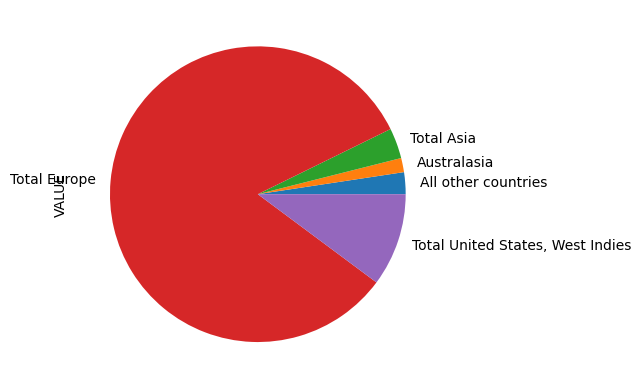

In [10]:
df_origin_1955_main_regions_summed.set_index("Last permanent residence")["VALUE"].plot.pie()

<Axes: ylabel='VALUE'>

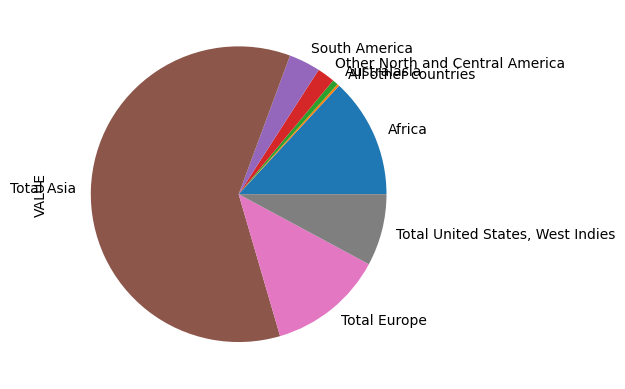

In [11]:
df_origin_2013_main_regions_summed.set_index("Last permanent residence")["VALUE"].plot.pie()